# Week 3 RAG Assignment

## 1. Indexing & Retrieval

### Setup & Imports

In [19]:
import json
import os
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document

load_dotenv()
print("API key loaded:", "OPENAI_API_KEY" in os.environ)

API key loaded: True


### Load Problem Codes & Create Documents

In [20]:
with open("problem_codes.json") as f:
    problem_codes = json.load(f)

documents = []
for pc in problem_codes:
    content = (
        f"Code: {pc['code']}\n"
        f"Category: {pc['category']}\n"
        f"Subcategory: {pc['subcategory']}\n"
        f"Description: {pc['description']}\n"
        f"Typical Severity: {pc['typical_severity']}\n"
        f"Keywords: {', '.join(pc['keywords'])}"
    )
    doc = Document(
        page_content=content,
        metadata={
            "code": pc["code"],
            "category": pc["category"],
            "subcategory": pc["subcategory"],
            "typical_severity": pc["typical_severity"],
        },
    )
    documents.append(doc)

print(f"Created {len(documents)} documents")
print(f"\nExample document:\n{documents[0].page_content}")

Created 21 documents

Example document:
Code: PLUMB-001
Category: Plumbing
Subcategory: Pipe Leak / Burst Pipe
Description: Water leaking or flooding from pipes, including burst pipes, leaking joints, and water supply line failures. May involve ceiling leaks, wall leaks, or floor flooding.
Typical Severity: High to Critical
Keywords: water, leak, pipe, burst, flooding, dripping, ceiling, soaked


### Index into ChromaDB Vector Store

In [21]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    collection_name="problem_codes"
)

print(f"Indexed {vectorstore._collection.count()} documents into ChromaDB")

Indexed 42 documents into ChromaDB


### Create Retriever

In [22]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

### Test Retrieval

In [23]:
test_queries = [
    "Water is pouring from the ceiling and the carpet is soaked",
    "The elevator is stuck between floors and people are trapped",
    "There's a flickering light in the break room",
    "I smell gas in the building",
    "The AC isn't working and it's really hot in here",
]

for query in test_queries:
    print(f"Query: {query}")
    print("-" * 60)
    results = retriever.invoke(query)
    for i, doc in enumerate(results, 1):
        print(f"  {i}. [{doc.metadata['code']}] {doc.metadata['subcategory']} "
              f"(Severity: {doc.metadata['typical_severity']})")
    print()

Query: Water is pouring from the ceiling and the carpet is soaked
------------------------------------------------------------
  1. [PLUMB-001] Pipe Leak / Burst Pipe (Severity: High to Critical)
  2. [PLUMB-001] Pipe Leak / Burst Pipe (Severity: High to Critical)
  3. [PLUMB-002] Roof Leak (Severity: High)

Query: The elevator is stuck between floors and people are trapped
------------------------------------------------------------
  1. [ELEV-001] Elevator Entrapment (Severity: Critical)
  2. [ELEV-001] Elevator Entrapment (Severity: Critical)
  3. [ELEV-002] Elevator Malfunction (Severity: Medium)

Query: There's a flickering light in the break room
------------------------------------------------------------
  1. [ELEC-002] Lighting Issue (Severity: Low to Medium)
  2. [ELEC-002] Lighting Issue (Severity: Low to Medium)
  3. [DOOR-002] Broken Glass / Window (Severity: High)

Query: I smell gas in the building
------------------------------------------------------------
  1. [SAFE-0

### Test with Actual Transcripts

In [24]:
with open("transcripts.json") as f:
    transcripts = json.load(f)

# Test with the first 5 transcripts
correct = 0
total = 5

for tx in transcripts[:total]:
    results = retriever.invoke(tx["transcript"])
    top_code = results[0].metadata["code"]
    match = "✓" if top_code == tx["true_category"] else "✗"
    if top_code == tx["true_category"]:
        correct += 1

    print(f"[{tx['id']}] Expected: {tx['true_category']} | Got: {top_code} {match}")
    print(f"  Top 3: {[r.metadata['code'] for r in results]}")
    print()

print(f"Retrieval accuracy (top-1): {correct}/{total} = {correct/total:.0%}")

[TX-001] Expected: PLUMB-001 | Got: PLUMB-001 ✓
  Top 3: ['PLUMB-001', 'PLUMB-001', 'PLUMB-002']

[TX-002] Expected: ELEC-002 | Got: ELEC-002 ✓
  Top 3: ['ELEC-002', 'ELEC-002', 'HVAC-003']

[TX-003] Expected: ELEV-001 | Got: ELEV-001 ✓
  Top 3: ['ELEV-001', 'ELEV-001', 'ELEV-002']

[TX-004] Expected: HVAC-001 | Got: HVAC-001 ✓
  Top 3: ['HVAC-001', 'HVAC-001', 'HVAC-003']

[TX-005] Expected: DOOR-002 | Got: DOOR-002 ✓
  Top 3: ['DOOR-002', 'DOOR-003', 'DOOR-003']

Retrieval accuracy (top-1): 5/5 = 100%


## 2. Make Graph Nodes

### Graph State & LLM Setup

In [25]:
from typing import Optional
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict


class GraphState(TypedDict):
    transcript: str                          # input: raw call transcript
    query: str                               # search query for the retriever
    documents: list[Document]                # retrieved problem code documents
    generation: Optional[str]                # final answer / classification
    iter: int                             # number of iterations


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

### Node 1: `generate_query_or_respond`

The LLM reads the transcript and decides if it can answer directly or needs to retrieve from the problem codes db.

In [26]:
class RouteDecision(BaseModel):
    """Pydantic field for agent understanding of routing decision"""
    action: str = Field(description="Either 'retrieve' or 'respond'")
    query: Optional[str] = Field(
        default=None,
        description="Search query for the problem codes database (only if action='retrieve')",
    )
    response: Optional[str] = Field(
        default=None,
        description="Direct response to the user (only if action='respond')",
    )


ROUTE_PROMPT = """You are a building maintenance call classifier.

Given a call transcript, decide whether you need to look up problem codes from the 
maintenance database to classify the issue.

- If the transcript describes a maintenance issue, set action="retrieve" and write a 
  short search query that captures the core problem (e.g. "water leak from ceiling pipe burst").
- If the transcript is NOT about a maintenance issue (e.g. a wrong number, a general 
  inquiry), set action="respond" and write a brief response.

Transcript:
{transcript}"""


def generate_query_or_respond(state: GraphState) -> dict:
    router = llm.with_structured_output(RouteDecision)
    decision = router.invoke(ROUTE_PROMPT.format(transcript=state["transcript"]))

    if decision.action == "respond":
        return {"generation": decision.response, "query": "", "documents": [], "iter": 0}

    return {"query": decision.query, "documents": [], "iter": 0}

### Node 2: `retrieve`

Runs the search query against vector store.

In [27]:
def retrieve(state: GraphState) -> dict:
    docs = retriever.invoke(state["query"])
    return {"documents": docs}

### Node 3: `grade_documents`

The LLM checks each retrieved problem code and decides if it's relevant to the transcript. If none are relevant, the graph will route to `rewrite_question` instead of `generate_answer`.

In [28]:
class GradeResult(BaseModel):
    """For agent understanding of the problem code grade"""
    relevant: bool = Field(description="True if the problem code is relevant to the transcript")


GRADE_PROMPT = """You are grading the relevance of a retrieved problem code to a maintenance call transcript.

Problem code:
{document}

Transcript:
{transcript}

Is this problem code relevant to the issue described in the transcript? Answer True or False."""


def grade_documents(state: GraphState) -> dict:
    """Grade each retrieved document for relevance. Keep only relevant ones."""
    grader = llm.with_structured_output(GradeResult)
    relevant_docs = []

    for doc in state["documents"]:
        grade = grader.invoke(
            GRADE_PROMPT.format(document=doc.page_content, transcript=state["transcript"])
        )
        if grade.relevant:
            relevant_docs.append(doc)

    return {"documents": relevant_docs}

### Node 4: `rewrite_question`

If the grader found no relevant documents, this node rewrites the search query to improve retrieval on the next attempt.

In [29]:
REWRITE_PROMPT = """You are rewriting a search query to better match problem codes in a building 
maintenance database. The previous query didn't retrieve relevant results.

The database contains codes for: plumbing (leaks, toilets, roof), electrical (power, lighting, 
hazards), HVAC (cooling, heating, air quality), elevators, doors & access, life safety (gas, fire, 
slip hazards), janitorial, pest control, and grounds/exterior.

Original transcript:
{transcript}

Previous query:
{query}

Write an improved search query that better captures the maintenance issue. Focus on the core 
problem category and relevant keywords."""


def rewrite_question(state: GraphState) -> dict:
    """Rewrite the search query and increment iter counter"""
    improved = llm.invoke(
        REWRITE_PROMPT.format(transcript=state["transcript"], query=state["query"])
    )
    return {"query": improved.content, "iter": state["iter"] + 1}

### Node 5: `generate_answer`

Uses the relevant retrieved problem codes to classify the transcript — selecting the best-matching code, severity, and routing recommendation.

In [30]:
GENERATE_PROMPT = """You are classifying a building maintenance call. Based on the transcript and 
the relevant problem codes retrieved from the database, provide your classification.

Transcript:
{transcript}

Relevant problem codes:
{codes}

Respond with:
- Selected code (e.g. PLUMB-001)
- Severity (Critical / High / Medium / Low)
- Confidence (0.0 to 1.0)
- Brief reasoning for your selection
- Recommended routing (who should handle this)

Format your response clearly with labeled fields."""


def generate_answer(state: GraphState) -> dict:
    """Generate a classification using the transcript and relevant retrieved codes"""
    codes_text = "\n\n".join(doc.page_content for doc in state["documents"])
    result = llm.invoke(
        GENERATE_PROMPT.format(transcript=state["transcript"], codes=codes_text)
    )
    return {"generation": result.content}

## 3. Wire the Graph

In [31]:
#for sake of test
MAX_ITER = 2


def route_after_query(state: GraphState) -> str:
    if state.get("generation"):
        return END
    return "retrieve"


def route_after_grading(state: GraphState) -> str:
    if state["documents"]:
        return "generate_answer"
    if state["iter"] >= MAX_ITER:
        return "generate_answer"  
    return "rewrite_question"


workflow = StateGraph(GraphState)

workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)

#creating edges

#route to generating or retrieval based on state
workflow.add_conditional_edges("generate_query_or_respond", route_after_query, {END: END, "retrieve": "retrieve"})

workflow.set_entry_point("generate_query_or_respond")
workflow.add_edge("retrieve", "grade_documents")

#route to generating or rewriting based on state
workflow.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {"generate_answer": "generate_answer", "rewrite_question": "rewrite_question"},
)
workflow.add_edge("rewrite_question", "retrieve")
workflow.add_edge("generate_answer", END)

graph = workflow.compile()
print("Graph compiled successfully!")

Graph compiled successfully!


### Visual Display

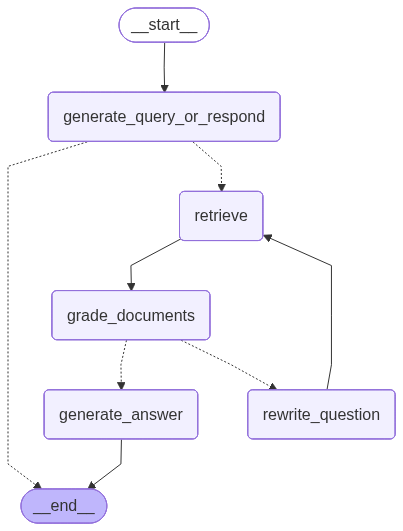

In [32]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Test the Graph

In [33]:
with open("transcripts.json") as f:
    transcripts = json.load(f)

# output result of first transcript
test = transcripts[0]
print(f"Transcript: {test['transcript'][:100]}...")
print(f"Expected: {test['true_category']}\n")

result = graph.invoke({"transcript": test["transcript"]})

print("Query used:", result.get("query"))
print(f"Iterations: {result.get('iter', 0)}")
print(f"Docs kept after grading: {len(result.get('documents', []))}")
print(f"\nClassification:\n{result['generation']}")

Transcript: Hi, I'm calling from the third floor of the Westfield office building at 200 Main Street. There's wa...
Expected: PLUMB-001



/Users/shahinsheikh/turing_engagement/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteDecision(action='ret...e issue', response=None), input_type=RouteDecision])
  return self.__pydantic_serializer__.to_python(
/Users/shahinsheikh/turing_engagement/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeResult(relevant=True), input_type=GradeResult])
  return self.__pydantic_serializer__.to_python(
/Users/shahinsheikh/turing_engagement/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expe

Query used: water leak from ceiling near suite 310 due to pipe issue
Iterations: 0
Docs kept after grading: 2

Classification:
- **Selected code:** PLUMB-001  
- **Severity:** Critical  
- **Confidence:** 1.0  
- **Brief reasoning for your selection:** The transcript describes a significant water leak from the ceiling, which is likely due to a pipe issue. The urgency of the situation is emphasized by the rapid spread of water and the soaked carpet, indicating a serious plumbing problem that requires immediate attention.  
- **Recommended routing:** Plumbing maintenance team should handle this issue immediately.
